# 01 — Exploratory Data Understanding (Online Retail II)

## Purpose
This notebook performs exploratory analysis to understand the Online Retail II dataset used in the project:
**Customer Lifetime Value (CLV) with Long-Term Optimization**.

This notebook answers:
- What is the structure and coverage of the dataset?
- What major data quality issues exist (returns, cancellations, missing IDs, invalid prices)?
- What do key distributions look like (revenue, invoice size, activity over time)?
- What assumptions will we need to justify for downstream modeling?

## Important note
- This notebook does not implement cleaning rules.
- Cleaning rules are implemented in `src/cleaning/clean_transactions.py`.
- Here we only observe, quantify, and justify decisions.

In [1]:
from __future__ import annotations

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

In [4]:
raw_path = "/Users/ramesh/Desktop/clv-long-term-optimization/data/interim/transactions_raw.parquet"
df = pd.read_parquet(raw_path)

df.shape

(1067371, 9)

In [5]:
df.head(10)

,invoice,stock_code,description,quantity,invoice_dt,unit_price,customer_id,country,source_sheet
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,Year 2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,Year 2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,Year 2009-2010
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,Year 2009-2010
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,Year 2009-2010
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085,United Kingdom,Year 2009-2010
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,Year 2009-2010
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085,United Kingdom,Year 2009-2010
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085,United Kingdom,Year 2009-2010
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085,United Kingdom,Year 2009-2010


In [6]:
df.dtypes

invoice         string[python]
stock_code      string[python]
description     string[python]
quantity                 Int64
invoice_dt      datetime64[ns]
unit_price             float64
customer_id              Int64
country         string[python]
source_sheet            object
dtype: object

In [7]:
df.isna().mean().sort_values(ascending=False).head(20)

customer_id     0.227669
description     0.004105
invoice         0.000000
stock_code      0.000000
quantity        0.000000
invoice_dt      0.000000
unit_price      0.000000
country         0.000000
source_sheet    0.000000
dtype: float64

In [8]:
summary = pd.DataFrame(
    {
        "rows": [len(df)],
        "customers": [df["customer_id"].nunique(dropna=True)],
        "invoices": [df["invoice"].nunique(dropna=True)],
        "countries": [df["country"].nunique(dropna=True)],
        "min_date": [df["invoice_dt"].min()],
        "max_date": [df["invoice_dt"].max()],
        "missing_customer_rate": [df["customer_id"].isna().mean()],
        "missing_datetime_rate": [df["invoice_dt"].isna().mean()],
    }
)

summary

,rows,customers,invoices,countries,min_date,max_date,missing_customer_rate,missing_datetime_rate
0,1067371,5942,53628,43,2009-12-01 07:45:00,2011-12-09 12:50:00,0.227669,0.0


## Data quality signals (what we need to measure)

In retail transaction data, typical issues include:
- Cancellations (invoices starting with "C")
- Returns (negative quantities)
- Zero or negative prices
- Missing customer IDs (cannot assign to a customer for CLV/churn)
- Duplicate rows
- Outliers

We quantify these issues here to justify downstream cleaning rules.

In [9]:
dq = {
    "cancellation_rate": df["invoice"].astype("string").str.startswith("C", na=False).mean(),
    "negative_quantity_rate": (df["quantity"].fillna(0) < 0).mean(),
    "nonpositive_quantity_rate": (df["quantity"].fillna(0) <= 0).mean(),
    "nonpositive_price_rate": (df["unit_price"].fillna(0) <= 0).mean(),
    "duplicate_row_rate": df.duplicated().mean(),
}

pd.Series(dq).sort_values(ascending=False)

negative_quantity_rate       0.021501
nonpositive_quantity_rate    0.021501
cancellation_rate            0.018264
duplicate_row_rate           0.011367
nonpositive_price_rate       0.005815
dtype: float64

In [10]:
# revenue is not computed in ingestion stage; compute quick diagnostic only
diag = df.copy()
diag["quantity"] = pd.to_numeric(diag["quantity"], errors="coerce")
diag["unit_price"] = pd.to_numeric(diag["unit_price"], errors="coerce")
diag["diag_revenue"] = diag["quantity"] * diag["unit_price"]

diag["diag_revenue"].describe(percentiles=[0.5, 0.9, 0.95, 0.99])

count     1067371.0
mean      18.069866
std      292.420223
min       -168469.6
50%             9.9
90%            31.8
95%            59.5
99%           180.0
max        168469.6
Name: diag_revenue, dtype: Float64

In [11]:
inv = diag.dropna(subset=["customer_id", "invoice_dt"]).copy()
inv = (
    inv.groupby(["customer_id", "invoice"], as_index=False)
    .agg(invoice_dt=("invoice_dt", "min"), invoice_value=("diag_revenue", "sum"))
)

inv["invoice_value"].describe(percentiles=[0.5, 0.9, 0.95, 0.99])

count        44876.0
mean      370.984321
std      1575.326258
min        -168469.6
50%           240.57
90%          762.685
95%         1121.235
99%        3242.4475
max         168469.6
Name: invoice_value, dtype: Float64

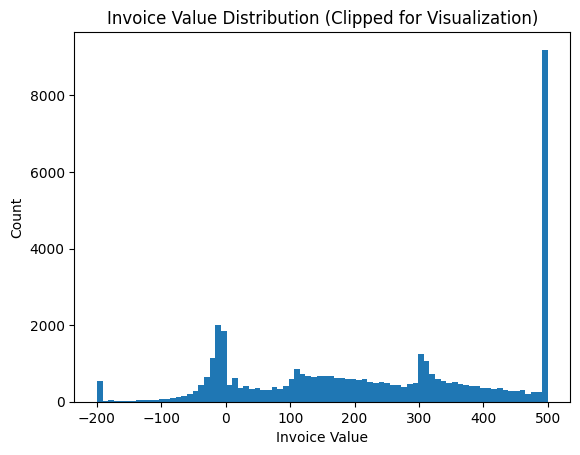

In [12]:
plt.figure()
plt.hist(inv["invoice_value"].clip(lower=-200, upper=500), bins=80)
plt.title("Invoice Value Distribution (Clipped for Visualization)")
plt.xlabel("Invoice Value")
plt.ylabel("Count")
plt.show()

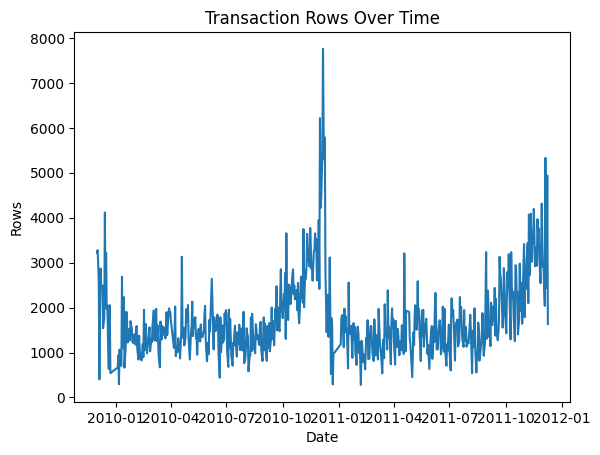

In [13]:
ts = df.dropna(subset=["invoice_dt"]).copy()
ts["date"] = ts["invoice_dt"].dt.date

daily = ts.groupby("date").size().rename("rows").reset_index()

plt.figure()
plt.plot(pd.to_datetime(daily["date"]), daily["rows"])
plt.title("Transaction Rows Over Time")
plt.xlabel("Date")
plt.ylabel("Rows")
plt.show()

## Key Findings (Exploratory Data Analysis)

- The dataset contains **cancellation transactions**, identifiable by invoice codes starting with `"C"`, as well as **return-like transactions** with negative quantities, which do not represent genuine purchase behavior.

- A non-trivial number of records have **missing `customer_id` values**, making them unsuitable for customer-level analysis such as CLV estimation or churn modeling.

- The data includes **non-positive unit prices and quantities**, which would distort revenue, frequency, and monetary calculations if not removed.

- Invoice-level revenue exhibits a **highly skewed, heavy-tailed distribution**, where a small fraction of invoices account for a disproportionately large share of total revenue. This confirms that average-based heuristics are inappropriate for value estimation.

- Transaction volume **varies significantly over time**, with clear spikes and periods of elevated activity, indicating non-stationary purchasing behavior and the importance of time-aware modeling.

These observations **justify the business-driven cleaning rules** applied in Step 2 and motivate the use of **probabilistic, time-based models** for CLV estimation, churn risk assessment, and downstream decision optimization.